> important action points
1. There is a difference between Boolean sensitivity (an integer number) and Boolean influence (a fraction between 0 and 1). What we are looking for is probably the **average Boolean sensitivity**

## Interpreting Boolean sensitivity

Let us begin by studying a single node $v_i \in V$ with state $s_i^t$ at time $t$. This node had neighbourhood $\mathcal{N}(v_i)$. Like all other nodes, this node follows a local outer-totalistic update rule defined by the choice of the resolution, the survive set, and the born set, summarised as $R_r B_\beta S_\sigma$. In other words, the local update rule is
$$
s_i^{t+1} = \phi_{r,\sigma,\beta}(s_i^t, \rho_i^t), \qquad \text{with} \quad \rho_i^t = \frac{1}{|\mathcal{N}(v_i)|}\sum_{j\in \mathcal{N}(v_i)} s_j^t.
$$
Now, we want to evaluate **how often flipping the state of a single node in a particular configuration would flip the value of $s_i^{t+1}$**. For any given global configuration, we may identify a partition of all nodes:
1. $\{v_i\}$, i.e. the node itself,
2. $\mathcal{N}(v_i)$, i.e. the neighbourhood of node $v_i$,
3. All other nodes that are not in $\mathcal{N}^*(v_i)$.

Here $\mathcal{N}^*(v_i) = \{v_i\} \cup \mathcal{N}(v_i)$.
We may introduce defects (i.e. flip the state of a single node) at time $t$ in either of these subsets.
1. Introducing a defect in $v_i$ will by definition affect the value of $s_i^t$.
2. Introducing a defect in a single node in $\mathcal{N}(v_i)$ will affect the value of $\rho_i^t$
3. Introducing a defect in a node in $V \setminus \mathcal{N}^*(v_i)$ will affect neither $s_i^t$ nor $\rho_i^t$.

### _a concrete simple example_

Now, as an example, consider a node $v_i$ with two neighbours $v_l, v_r \in \mathcal{N}(v_i)$. Together they form what we may call the totalistic neighbourhood $\mathcal{N}^*(v_i) = \mathcal{N}(v_i) \cup \{v_i\} = \{v_l, v_r, v_i\}$. This totalistic neighbourhood can take $2^{1+2} = 8$ configurations.

For notational purposes, let us pick an arbitrary order $(v_l, v_i, v_r)$. The set of possible configurations can then be written out as
$$
P = \{(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1), (1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)\} = \{0, 1\}^3.
$$
Each of these configurations can be perturbed in three different ways, by introducing a defect in any of the nodes. Let us first consider a partition of the set of configurations based on the sum of the states of $v_l$ and $v_r$:
$$
P = \{(0, 0, 0), (0, 1, 0)\} \cup \{(0, 0, 1), (1, 0, 0), (0, 1, 1), (1, 1, 0)\} \cup \{(1, 0, 1), (1, 1, 1)\} = P_0 \cup P_1 \cup P_2,
$$
where the index is equal to the **sum of living neighbours**. Note that $|P_0| = |P_2| = 2$, while $|P_1| = 4$. Each of these subsets can be partitioned further into two subsubsets of equal cardinality, depending on the value of $v_i$, so
$$
\begin{align*}
P_0 &= P_{0,0} \cup P_{0,1} = \{(0, 0, 0)\} \cup \{(0, 1, 0)\},\\
P_1 &= P_{1,0} \cup P_{1,1} = \{(0, 0, 1), (1, 0, 0)\} \cup \{(0, 1, 1), (1, 1, 0)\},\\
P_2 &= P_{2,0} \cup P_{2,1} = \{(1, 0, 1)\} \cup \{(1, 1, 1)\}.
\end{align*}
$$
In other words, the total set of configuration can be written as a double indexed union
$$
P = \bigcup_{s_i \in \{0,1\}} \bigcup_{q=0}^2 P_{{s_i},q}
$$
Due to the outer-totalistic nature of our family of network automata, configurations in the same subsubset $P_{{s_i},q}$ will always result in the same value of the node $v_i$ in the next time step. Configurations in a different subsubset may or may not result in the same value. The more they do, the higher our total Boolean sensitivity is said to be.

Now, elaborating a bit more on our concrete simple example, say that we introduce a defect in a random node of a configuration in $P_{1,0}$.
1. There is a probability of $1/3$ that this node is the central node $v_i$, which would map the configuration from $P_{1,0} \rightarrow P_{1,1}$.
2. There is a probability of $2/3$ that this node is in $\mathcal{N}(v_i)$. Because of the distribution of states, there are two possibilites:
    - There is a probability of $1/2$ that the sum of states increases, which maps the configuration from $P_{1,0} \rightarrow P_{2,0}$,
    - There is a probability of $1/2$ that the sum of state decreases, such that $P_{1,0} \rightarrow P_{0,0}$.

The first probability depends on the number of nodes in the neighbourhood of $v_i$. The second probability depends on how many living neighbours there are: changing a living neighour's state will decrease the density, while changing a dead neighbour's state will increase the density.

## Defining Boolean sensitivity for an outer-totalistic local update rule
(_for a single node, and for a uniform random initial configuration_)

Let us consider the case where every configuration is equally likely (uniform distribution). Let us call $d_i = |\mathcal{N}(v_i)| > 0$ the degree of node $v_i$. Following the principles outlined above, we then find that the total Boolean sensitivity related to node $v_i$ is
$$
S_i = \frac{1}{2^{d_i+1}}\sum_{s \in \{0,1\}} \sum_{q=0}^{d_i}\binom{d_i}{q} \left\{ \frac{1}{d_i+1}\text{IS}(s_i, q, d_i) + \frac{d_i}{d_i+1}\left[\frac{q}{d_i}\text{NS}_\text{dec}(s_i, q, d_i) + \frac{d_i-q}{d_i}\text{NS}_\text{inc}(s_i, q, d_i)\right]\right\}.
$$
Here we call upon two terms. The first expresses how _sensitive_ the node's state in the next time step is to changing its _identity_ (i.e. its own original state). We call this the **identity sensitivity**,
$$
\text{IS}(s_i, q, d_i) = \phi\left(s_i,\frac{q}{d_i}\right) \oplus \phi\left(s_i \oplus 1, \frac{q}{d_i}\right),
$$
where $\oplus$ is the XOR operator. The IS takes the value $1$ if the output of the function changes upon flipping state $s_i$, and $0$ otherwise. Note that $\text{IS}(s_i, q, d_i)$ does not actually depend on the state $s_i$, but only what happens to the output when you flip it. After all, $\text{IS}(s_i, q, d_i) = \text{IS}(s_i \oplus 1, q, d_i)$.

The second term expresses how _sensitive_ the node's state in the next time step is to changing the density of its _neighbourhood_. Depending on the configuration of the neighbourhood, the density can be _increased_ or _decreased_,
$$
\begin{align*}
\text{NS}_\text{dec}(s_i, q, d_i) &= \phi\left(s_i,\frac{q-1}{d_i}\right) \oplus \phi\left(s_i,\frac{q}{d_i}\right)\\
\text{NS}_\text{inc}(s_i, q, d_i) &= \phi\left(s_i,\frac{q+1}{d_i}\right)\oplus \phi\left(s_i,\frac{q}{d_i}\right)
\end{align*}
$$

Note that $\phi(s,\rho)$ is undefined for $\rho \not\in [0,1]$, but terms involving that expression do not contribute to the sum, because in those cases either $q=0$ or $(d_i-q)=0$. We call the weighted sum of both possibilities the **neighbourhood sensitivity**. Additionally, note that the factor $d_i$ typically means that the neighbourhood sensitivity will contribute (much) more to the total Boolean sensitivity than the identity sensitivity.

For the sake of being complete, let us again run over all contributing elements
1. We divide over $2^{d_i+1}$, the total number of configurations in $P$ (all possible configurations of nodes in $\mathcal{N}^*(v_i)$).
2. We sum over the values of $q$, and multiply by the binomium $\binom{d_i}{q}$. After all, this is the number of configurations that correspond to $q$ living neighbours in $\mathcal{N}(v_i)$.
3. The prefactors $\frac{1}{d_i+1}$ and $\frac{d_i}{d_i+1}$ indicate the fraction of perturbations that affect resp. the node $v_i$ or the nodes in $\mathcal{N}(v_i)$.
4. The prefactors $\frac{q}{d_i}$ and $\frac{d_i-q}{d_i}$ indicate the fraction of perturbations that affect resp. living nodes or dead nodes in $\mathcal{N}(v_i)$.

Concluding, we can write this more elegantly. Isolating some common factors, we find
$$
\boxed{
S_i = \frac{2^{-(d_i+1)}}{(d_i+1)}\sum_{s \in \{0,1\}} \sum_{q=0}^{d_i}\binom{d_i}{q} \Big\{ \text{IS}(s_i, q, d_i) + \text{NS}(s_i, q, d_i)\Big\}.
}
$$
with
$$
\text{NS}(s_i, q, d_i) = q\text{NS}_\text{dec}(s_i, q, d_i) + (d_i-q)\text{NS}_\text{inc}(s_i, q, d_i)
$$

The highest possible value of the IS is $1$, and that of the NS is $d_i$. Note that the value of $S_i$ therefore runs from $0$ to $1$, as desired. We should note that this distinction between NS and IS is not commonplace, but we introduced it because of the clear visual interpretation that it offers.

## Visual interpretation of IS and NS

In order to make the interpretation of IS and NS more clear, consider the LLNA $R_3 B_6 S_3$. Additionally, consider that we still inspect the behaviour of node $v_i$ that only has two neighbours. The density of living neighbours can therefore only be $0$, $1/2$ or $1$. This is indicated in the LLNA diagram below.

In [144]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


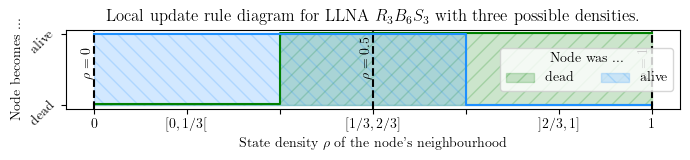

In [115]:
SAVEFIG=False

fig, ax = plt.subplots(1,1,figsize=(7,1.7))

# define model
resolution = 3
born_if = [1,2]
survive_if = [0,1]
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

# draw diagram
model.diagram(ax=ax)

for rho in [0, 1/2, 1]:
    ax.axvline(rho, color='k', ls='--')
    ax.text(rho-.025, 1-.618, fr"$\rho={np.round(rho,1)}$", rotation=90)
# set title
ax.set_title(f"Local update rule diagram for LLNA {model.__str__(latex=True)} with three possible densities.")

fig.tight_layout()
if SAVEFIG:
    # Note: saving as PDF fails to show the hatches
    plt.savefig(f"update-rule-diagram_rule{model.__str__()}.png", dpi=600)

When performing the double summation in the boxed equation seen earlier, the visual interpretation is as follows:
1. When $s_i = 0$, we only look at the green diagram (with diagonals going to the upper right). When $s_i = 1$, we only look at the blue diagram (with diagonals going to the upper left)
2. For a value $q$, we look at the location in the diagram indicated by the vertical dashed line corresponding to $\rho = q/d_i$.

Then, having chosen a location to consider, calculate the number of neighbourhood configuration that can result in this location: $\binom{d_i}{q}$. Then count the following

1. When changing colour at this location, does the output change? If so, add $1$.
2. When moving to the left (if possible), does the output change? If so, add $q$.
3. When moving to the right (if possible), does the output change? If so, add $d_i-q$.

This results in a number that you should multiply by the factor $\binom{d_i}{q}$. Then move on to the next step in the dobule summation.

Some remarks may be of interest:
- Every combination of local update rule and degree $d_i$ is associated with a single value for the Boolean sensitivity $S_i$.
- The number of possible $S_i$ values is limited by the discrete nature of the problem, and also by two additional identities:
    - $\text{IS}(s_i, q, d_i) = \text{IS}(s_i \oplus 1, q, d_i),$
    - $\text{NS}_\text{dec}(s_i, q, d_i) = \text{NS}_\text{inc}(s_i, q+1, d_i)$
- the number of possible $S_i$ values for high ratios of $d_i/r$ is also limited, because in that case most perturbations in the neighbourhood will not alter the density so much that it changes from density interval. (we could implement this in the formula, but it's not that much computational work to just also calculate the superfluous cases). This is more or less the same as saying someone with a lot of friends does not easily change their mind.

## Calculating the Boolean sensitivity

In [182]:
def id_sens(model, sum_value, degree):
    ### recall that de IS does not actually depend on the state of node itself, only on what happens when it's flipped
    # raise exception if numbers don't match up
    if sum_value < 0 or sum_value > degree:
        # there will be no change
        raise Exception("The sum of the neighbourhood nodes must be smaller than the degree")
    # find density and which interval it belongs to (from one-hot vector)
    rho = tc.tensor([sum_value / degree])
    rho_interval_idx = int(model.interval_encoding(rho.unsqueeze(0))[0].argmax())
    # find B and S intervals
    born_if, survive_if = model.rule
    if (rho_interval_idx in born_if) == (rho_interval_idx in survive_if):
        # there will be no change
        return 0
    # otherwise there will be change
    return 1

def nbh_sens_inc(model, si, sum_value, degree):
    # raise exception if numbers don't match up
    if sum_value < 0 or sum_value > degree:
        # there will be no change
        raise Exception("The sum of the neighbourhood nodes must be smaller than the degree")
    # Note that increasing from sum=degree is not possible
    if sum_value == degree:
        # there will be no change
        return 0 # should not matter
    # find density and which interval it belongs to
    rho = tc.tensor([sum_value / degree])
    rho_interval_idx = int(model.interval_encoding(rho.unsqueeze(0))[0].argmax())
    # find INCREASED density and which interval it belongs to (from one-hot vector)
    rho_inc = tc.tensor([(sum_value + 1) / degree])
    rho_inc_interval_idx = int(model.interval_encoding(rho_inc.unsqueeze(0))[0].argmax())
    # find B and S intervals. Returns B intervals if si = 0, S intervals if si = 1
    born_or_survive_if = model.rule[int(si)]
    if (rho_interval_idx in born_or_survive_if) == (rho_inc_interval_idx in born_or_survive_if):
        # there will be no change
        return 0
    # otherwise there will be change
    return 1

def nbh_sens_dec(model, si, sum_value, degree):
    # raise exception if numbers don't match up
    if sum_value < 0 or sum_value > degree:
        # there will be no change
        raise Exception("The sum of the neighbourhood nodes must be smaller than the degree")
    # Note that decreasing from sum=0 is not possible
    if sum_value == 0:
        # should not matter
        return 0
    # find density and which interval it belongs to (from one-hot vector)
    rho = tc.tensor([sum_value / degree])
    rho_interval_idx = int(model.interval_encoding(rho.unsqueeze(0))[0].argmax())
    # find DECREASED density and which interval it belongs to
    rho_dec = tc.tensor([(sum_value - 1) / degree])
    rho_dec_interval_idx = int(model.interval_encoding(rho_dec.unsqueeze(0))[0].argmax())
    # find B and S intervals. Returns B intervals if si = 0, S intervals if si = 1
    born_or_survive_if = model.rule[int(si)]
    if (rho_interval_idx in born_or_survive_if) == (rho_dec_interval_idx in born_or_survive_if):
        # there will be no change
        return 0
    # otherwise there will be change
    return 1

def nbh_sens(model, si, sum_value, degree):
    NS_dec = nbh_sens_dec(model, si, sum_value, degree)
    NS_inc = nbh_sens_inc(model, si, sum_value, degree)
    return sum_value*NS_dec + (degree-sum_value)*NS_inc

Recall our formula
$$
\boxed{
S_i = \frac{2^{-(d_i+1)}}{(d_i+1)}\sum_{s \in \{0,1\}} \sum_{q=0}^{d_i}\binom{d_i}{q} \Big\{ \text{IS}(s_i, q, d_i) + \text{NS}(s_i, q, d_i)\Big\}.
}
$$
with
$$
\text{NS}(s_i, q, d_i) = q\text{NS}_\text{dec}(s_i, q, d_i) + (d_i-q)\text{NS}_\text{inc}(s_i, q, d_i)
$$

(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $R_{5}B_{6}S_{17}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

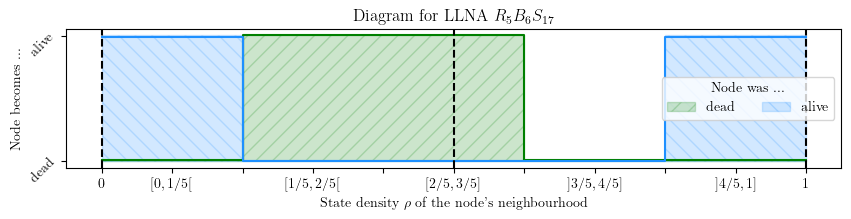

In [202]:
# some examples
resolution = 5
born_if = [1, 2]
survive_if = [0, 4]
degree = 2

model=LLNA(resolution, x=born_if, y=survive_if, iso=True)
model.diagram(degree=degree)

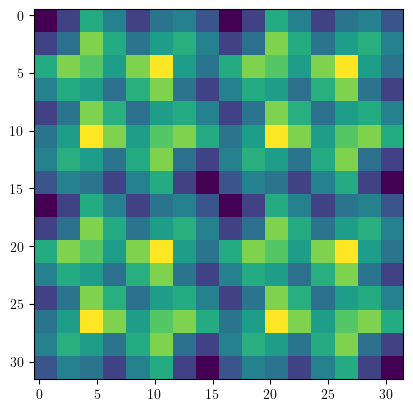

In [200]:
import math
def boolean_sens(model, degree):
    prefactor = 2**(-degree-1)/(degree+1)
    double_summation = 0
    for si in [0,1]:
        for sum_value in range(degree+1):
            binomium = math.comb(degree, sum_value)
            term = id_sens(model, sum_value, degree) + nbh_sens(model, si, sum_value, degree)
            double_summation += binomium*term
    return prefactor * double_summation

def binary_indices(n: int) -> list:
    """
    Returns a list of indices where bits are 1 in the binary representation of n.
    """
    return [i for i, bit in enumerate(bin(n)[:1:-1]) if bit == '1']

resolution = 5
degree = 79

sigmas=range(2**resolution)
betas=range(2**resolution)
BS_grid = np.zeros((2**resolution,2**resolution))

for beta in betas:
    born_if = binary_indices(beta)
    for sigma in sigmas:
        survive_if = binary_indices(sigma)
        model = LLNA(resolution, x=born_if, y=survive_if, iso=True)
        BS = boolean_sens(model, degree)
        BS_grid[beta, sigma] = BS

plt.imshow(BS_grid)

Note that this is point-mirrored! That should make sense from the LLNA rule diagram: if $B$ and $S$ sets are switched simultaneously, the result should be the same (i.e. $\beta \mapsto \sigma$ and $\sigma \mapsto \beta$ simultanously). After all, this does not affect the neighbourhood sensitivity (which stays within the same colour in the rule diagram), and it does not affect the identity sensitivity (because this only looks at what happens if colour changes, and does not care what the initial colour was).

There should be another symmetry as well, which in general only occurs in isomorphically defined LLNAs. Visually, in the rule diagram, we could also simultaneously 'mirror' both density interval sets to the other side. This corresponds to mapping
$$
\begin{align*}
\beta &\mapsto \sum_{i:R_i \in B} 2^{r-1-i},\\
\sigma &\mapsto \sum_{i:R_i \in S} 2^{r-1-i}
\end{align*}
$$
Also the combination of these two simultanous mappings results in an identical average Boolean sensitivity. In our family of isomorphic LLNAs, there should therefore always be at least four partitions of the rule space that generate identical average Boolean sensitivities. Let's inspect this.

In [ ]:
resolution = 5
degree = 9
beta, sigma = np.random.randint(0,2**resolution,2)
# beta = 20
# sigma = 10

born_if = binary_indices(beta)
survive_if_if = binary_indices(sigma)

# vanilla
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)
BS = boolean_sens(model, degree)
print('vanilla case', BS)

# switch sets (i.e. switch axes if they share an origin)
born_if_pm = survive_if
survive_if_pm = born_if
model_pm = LLNA(resolution, x=born_if_pm, y=survive_if_pm, iso=True)
BS_pm = boolean_sens(model_pm, degree)
print('switch sets', BS_pm)

# binary reversal (less straightforward visual interpretation)
born_if_br = resolution - 1 - np.array(born_if)
survive_if_br = resolution - 1 - np.array(survive_if)
model_br = LLNA(resolution, x=born_if_br, y=survive_if_br, iso=True)
BS_br = boolean_sens(model_br, degree)
print('binary reversal', BS_br)

# point-mirror and binary reversal (i.e. isomorphic, I think)
born_if_pm_br = resolution - 1 - np.array(survive_if)
survive_if_pm_br = resolution - 1 - np.array(born_if)
model_pm_br = LLNA(resolution, x=born_if_pm_br, y=survive_if_pm_br, iso=True)
BS_br = boolean_sens(model_pm_br, degree)
print('switch sets and binary reversal', BS_br)

vanilla case 0.15195312500000002
switch sets 0.15195312500000002
binary reversal 0.15195312500000002
switch sets and binary reversal 0.15195312500000002


In [289]:
# TODO: I should definitely look at a less computationally expensive way of programming the BS calculation, preferably without needing to create LLNA model objects. See other Notebook for that.
# TODO: it would be interesting to look at behaviour of LLNAs that have the same average Boolean sensitivity! If they have identical behaviour, we could for example make the rule space much smaller in a search query.

## Boolean sensitivity over all nodes

- As a first approximation, take sum over all nodes for $S_i$ for all its possible neighbourhood configurations
- As a second approximation, take a sum over all possible global configurations (or a sample thereof), summing the local $S_i$ for all nodes (in that case the neighbourhood configurations will be inter-dependent, which is more realistic)
- As a third step, generalise to non-uniform distributions
    - e.g. a probability of 70 percent living nodes
    - e.g. the probability of being alive is linked to the node degree
    - e.g. a Markov configuration, where linked nodes are more likely to be in the same state (check with ChatGPT how that would work in the context of a network, because contradictions may arise)

For a more general probability distribution:
$$
S_i = \sum_{s_i \in \{0,1\}} \sum_{q=0}^{d_i} P(s_i, q | d_i) \left\{ \frac{1}{d_i+1} \text{IS}(s_i, q, d_i) + \frac{d_i}{d_i+1} \left[ \frac{q}{d_i} \text{NS}_\text{dec}(s_i, q, d_i) + \frac{d_i-q}{d_i} \text{NS}_\text{inc}(s_i, q, d_i) \right] \right\}
$$
For example in a binomial distribution with probability of a living node $p$, the probability mass function is
$$
P(s_i, q | d_i) = \text{Binom}(s_i + q, d_i+1, p) = \binom{d_i+1}{s_i+q}p^{s_i+q}(1-p)^{d_i+1-s_i-q}
$$


## Boolean sensitivity over time
- The probability distribution of configurations changes over time because of the network automaton process
- It's quite easy to track what will happen to the average density
- This average density can be translated to the probability $p$ in the binomial distribution above
- This affects Boolean sensitivity
- Eventually we end up with something really close to the Lyapunov spectrum, I think?
- Make use of Derrida plots (from work from 80s)

In [ ]:
# TODO: make sure that the Boolean sensitivity is the same for isomorphic LLNAs!